# Manual Linear Regression

In [121]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from pathlib import Path

X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.reshape(-1,1)

X_val = pd.read_csv('../data/processed/X_valid_scaled.csv')
y_val = pd.read_csv('../data/processed/y_valid.csv').values.reshape(-1,1)

X_val.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.866764,0.004077,-0.211594,-0.088934,2.165000,-0.259789,0.873470,-0.597889,0.472844,-0.285504,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
1,0.074110,1.250061,0.145643,1.374088,-0.524174,0.751222,0.487465,1.498567,1.276986,-0.285504,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
2,-0.631546,-0.618916,-0.160826,-0.820445,0.372217,-1.433867,-1.683818,-0.597889,-0.971996,-0.285504,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
3,-0.161109,-0.885912,-0.529035,-0.088934,1.268609,-0.781602,-1.683818,-0.597889,-0.102477,-0.285504,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
4,-0.866764,0.849566,0.205338,2.105599,-0.524174,1.175195,1.114724,-0.192497,1.255193,-0.285504,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636


## Define Model

In [122]:
def model(x, w, b):
    y_pred = np.dot(x, w) + b
    return y_pred

## Define Cost Function

In [123]:
def cost_function(x, y, w, b):
    y_pred = model(x, w, b)
    mse = np.mean((y - y_pred) ** 2)
    return mse

## Computer Gradient Descent

In [124]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    y_pred = np.dot(x, w) + b
    error = y_pred.reshape(-1, 1) - y

    dw = (1 / m) * np.dot(x.T, error).flatten()
    db = (1 / m) * np.sum(error)

    return dw, db

## Hyper Parameters

In [125]:
np.random.seed(42)
w_init = np.random.randn(X_train.shape[1]) * 0.01
b_init = 0.0

learning_rate = 0.01
epochs = 5000

## Training Model

In [126]:
def fit(X_train, y_train, w_init, b_init, learning_rate, epochs, X_val=None, y_val=None):
    w = w_init.copy()
    b = b_init

    train_losses = []
    val_losses = []

    for i in range(epochs):
        dw, db = compute_gradient(X_train, y_train, w, b)

        w -= learning_rate * dw
        b -= learning_rate * db

        if i % 1000 == 0:
            train_loss = cost_function(X_train, y_train, w, b)
            train_losses.append(train_loss)

            if X_val is not None and y_val is not None:
                val_loss = cost_function(X_val, y_val, w, b)
                val_losses.append(val_loss)

            print(f"Epoch {i}, Train Loss: {train_loss:.4f}")

    return w, b, train_losses, val_losses

In [127]:
w_final, b_final, train_losses, val_losses = fit(
    X_train, y_train, w_init, b_init, learning_rate, epochs, X_val, y_val
)

Epoch 0, Train Loss: 142.0329
Epoch 1000, Train Loss: 0.2938
Epoch 2000, Train Loss: 0.2944
Epoch 3000, Train Loss: 0.2946
Epoch 4000, Train Loss: 0.2947


In [128]:
print("Training completed.")
print(f"Final training loss: {train_losses[-1] // 1e9:.4f}")
print(f"Final validation loss: {val_losses[-1] // 1e9:.4f}")

Training completed.
Final training loss: 0.0000
Final validation loss: 0.0000


## K-Fold Cross-Validation 

In [129]:
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import mean_squared_error
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse_scores = []

print("Performing 5-Fold Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)): 
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx] 
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx] 

    # Re-initialize model
    w_fold = np.random.randn(X_fold_train.shape[1]) * 0.01 
    b_fold = 0.0 

    # Train [Start training]
    w_fold, b_fold, _, _ = fit(
        X_fold_train, y_fold_train, w_fold, b_fold, learning_rate, epochs
    )

    # Evaluate
    y_pred_val = X_fold_val @ w_fold + b_fold 
    mse = mean_squared_error(y_fold_val, y_pred_val) 
    cv_mse_scores.append(mse)
    print(f"  Fold {fold+1} MSE: {mse:.4f}")

print(f"Cross-Validation MSE: {np.mean(cv_mse_scores):.4f} +/- {np.std(cv_mse_scores):.4f}")

Performing 5-Fold Cross-Validation...
Epoch 0, Train Loss: 141.8785
Epoch 1000, Train Loss: 0.2957
Epoch 2000, Train Loss: 0.2907
Epoch 3000, Train Loss: 0.2902
Epoch 4000, Train Loss: 0.2901
  Fold 1 MSE: 1.9920
Epoch 0, Train Loss: 142.0044
Epoch 1000, Train Loss: 0.2968
Epoch 2000, Train Loss: 0.2930
Epoch 3000, Train Loss: 0.2931
Epoch 4000, Train Loss: 0.2932
  Fold 2 MSE: 1.2933
Epoch 0, Train Loss: 141.7432
Epoch 1000, Train Loss: 0.2927
Epoch 2000, Train Loss: 0.2897
Epoch 3000, Train Loss: 0.2891
Epoch 4000, Train Loss: 0.2889
  Fold 3 MSE: 7.9923
Epoch 0, Train Loss: 141.9614
Epoch 1000, Train Loss: 0.3055
Epoch 2000, Train Loss: 0.3021
Epoch 3000, Train Loss: 0.3019
Epoch 4000, Train Loss: 0.3020
  Fold 4 MSE: 2.4145
Epoch 0, Train Loss: 141.8615
Epoch 1000, Train Loss: 0.3084
Epoch 2000, Train Loss: 0.3053
Epoch 3000, Train Loss: 0.3051
Epoch 4000, Train Loss: 0.3051
  Fold 5 MSE: 6.1532
Cross-Validation MSE: 3.9691 +/- 2.6246


## Final Test Prediction, Evaluation, and Distribution Curves

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

X_train_raw = pd.read_csv('../data/processed/X_train.csv')
X_final_test_raw = pd.read_csv('../data/processed/final_test.csv')

# Match final test columns with the training feature set before scaling.
X_final_test_raw = X_final_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

train_mean = X_train_raw.mean()
train_std = X_train_raw.std().replace(0, 1)
X_final_test_scaled = (X_final_test_raw - train_mean) / train_std
X_final_test_scaled = X_final_test_scaled.reindex(columns=X_train.columns, fill_value=0)

y_val_pred = (np.asarray(X_val) @ w_final + b_final).reshape(-1, 1)
y_final_test_pred = (np.asarray(X_final_test_scaled) @ w_final + b_final).reshape(-1, 1)

final_test_predictions = pd.DataFrame({
    'Predicted_SalePrice': y_final_test_pred.flatten()
})

print('Sample predictions from ../data/processed/final_test.csv')
final_test_predictions.head(10)

Sample predictions from ../data/processed/final_test.csv


,Predicted_SalePrice
0,11.696099
1,11.989576
2,12.085833
3,12.181616
4,12.211527
5,12.048720
6,12.107899
7,11.989110
8,12.150874
9,11.707332


In [134]:
y_val_true_flat = y_val.flatten()
y_val_pred_flat = y_val_pred.flatten()

# Accuracy, precision, recall, and F1-score are classification metrics, so regression metrics are reported here.
within_10pct_accuracy = np.mean(
    np.abs(y_val_true_flat - y_val_pred_flat) <= 0.10 * np.abs(y_val_true_flat)
)

regression_metrics = pd.DataFrame({
    'Metric': [
        'Custom Accuracy (within 10% error)',
        'MAE',
        'MSE',
        'RMSE',
        'R2 Score',
        'Explained Variance'
    ],
    'Value': [
        within_10pct_accuracy,
        mean_absolute_error(y_val_true_flat, y_val_pred_flat),
        mean_squared_error(y_val_true_flat, y_val_pred_flat),
        np.sqrt(mean_squared_error(y_val_true_flat, y_val_pred_flat)),
        r2_score(y_val_true_flat, y_val_pred_flat),
        explained_variance_score(y_val_true_flat, y_val_pred_flat)
    ]
})

print(f"Main Model Score (R2): {r2_score(y_val_true_flat, y_val_pred_flat):.4f}")
print(f"Within-10% Prediction Rate: {within_10pct_accuracy * 100:.2f}%")
print('Validation-set evaluation metrics for the manual linear regression model:')
print('Note: this is a regression model, so R2, MAE, MSE, and RMSE are more meaningful than classification accuracy.')
regression_metrics

Main Model Score (R2): 0.8698
Within-10% Prediction Rate: 100.00%
Validation-set evaluation metrics for the manual linear regression model:
Note: this is a regression model, so R2, MAE, MSE, and RMSE are more meaningful than classification accuracy.


,Metric,Value
0,Custom Accuracy (within 10% error),1.000000
1,MAE,0.099592
2,MSE,0.024299
3,RMSE,0.155880
4,R2 Score,0.869790
5,Explained Variance,0.869798


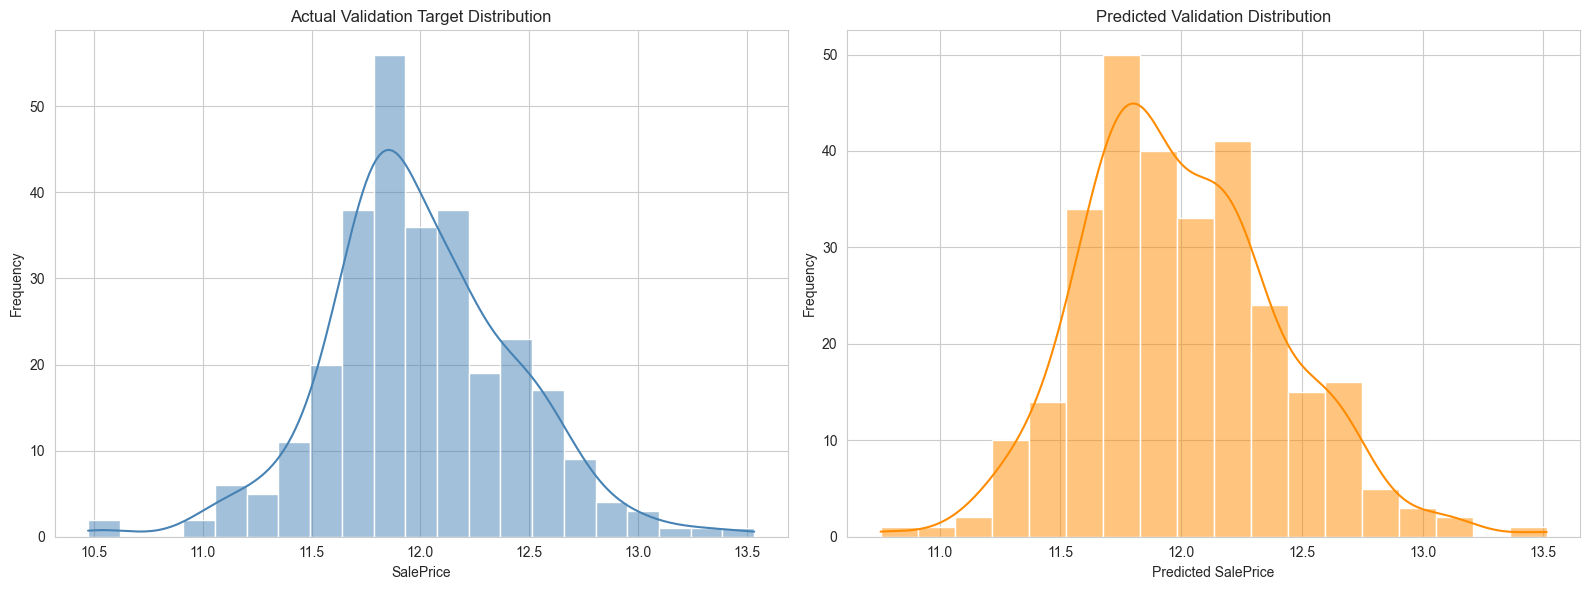

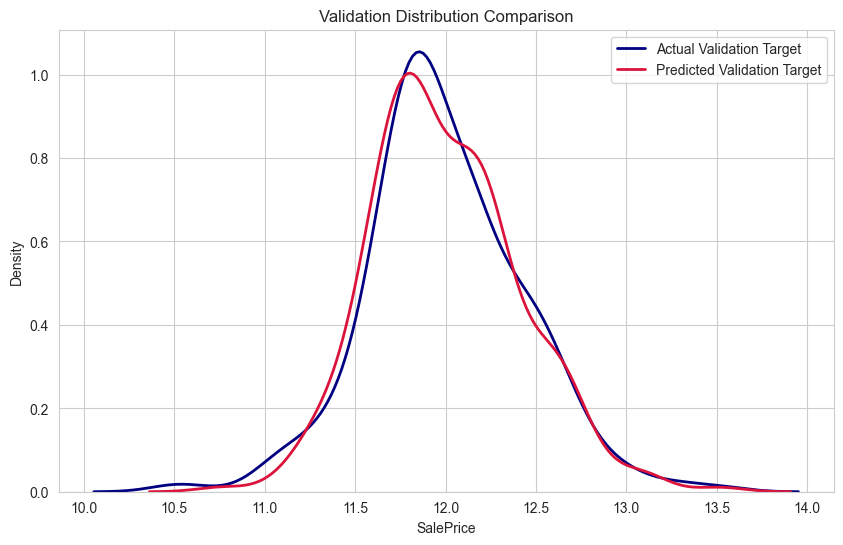

In [135]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(y_val_true_flat, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Actual Validation Target Distribution')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

sns.histplot(y_val_pred_flat, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Predicted Validation Distribution')
axes[1].set_xlabel('Predicted SalePrice')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(y_val_true_flat, label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(y_val_pred_flat, label='Predicted Validation Target', linewidth=2, color='crimson')
plt.title('Validation Distribution Comparison')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.legend()
plt.show()

## Save Model

In [137]:
import pickle

model_dir = Path('../models')
model_dir.mkdir(parents=True, exist_ok=True)

manual_linear_regression_model = {
    'model_name': 'manual_linear_regression',
    'weights': w_final,
    'bias': b_final,
    'learning_rate': learning_rate,
    'epochs': epochs,
    'feature_columns': list(X_train.columns)
}

model_path = model_dir / 'manual_linear_regression.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(manual_linear_regression_model, f)

print(f'Model saved successfully at: {model_path}')

Model saved successfully at: ..\models\manual_linear_regression.pkl
